In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from glob import glob
from nilearn import plotting
from nilearn import datasets

from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import smooth_img, new_img_like

In [2]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img

from nilearn import surface
from nilearn import datasets
fsaverage = datasets.fetch_surf_fsaverage()
mni152_template = datasets.load_mni152_template(resolution=1)


In [3]:
task_label = 'badaga'

bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/',
                        'SSP/data_bids/')
deriv_dir = os.path.join(bidsroot, 'derivatives')
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')

## Second-level analyses

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [4]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-SSP001', 'sub-SSP002',
               'sub-SSP005', 'sub-SSP012',
               'sub-SSP013', 'sub-SSP014', 
               'sub-SSP040', 'sub-SSP041', 'sub-SSP054', 
               'sub-SSP060', 'sub-SSP069', 'sub-SSP072', 'sub-SSP077',
               'sub-SSP081',
               ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [5]:
participants_fpath

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/participants.tsv'

In [6]:
print(participants_df)

   participant_id  age sex    group
0      sub-SSP008    9   M  control
1      sub-SSP009    9   M  control
2      sub-SSP011   11   M  control
3      sub-SSP015   10   M  control
4      sub-SSP017   11   M  control
5      sub-SSP018    8   F      CWS
6      sub-SSP020   13   F      CWS
7      sub-SSP021    8   M      CWS
8      sub-SSP028   10   M  control
9      sub-SSP032   12   M  control
10     sub-SSP033    7   F  control
11     sub-SSP034    9   F  control
12     sub-SSP036   11   M  control
13     sub-SSP038    9   M  control
14     sub-SSP039   12   M  control
15     sub-SSP045   10   M      CWS
16     sub-SSP046   10   M      CWS
17     sub-SSP048    9   M      CWS
18     sub-SSP051    8   F  control
19     sub-SSP056    8   F  control
20     sub-SSP062    8   M  control
21     sub-SSP064   12   M      CWS
22     sub-SSP074   10   M  control
23     sub-SSP078   11   M      CWS
24     sub-SSP083    9   F  control
25     sub-SSP084   11   M  control
26     sub-SSP085    8   F  

In [7]:
# create group-specific lists of subject IDs
sub_list_cwns = list(participants_df.participant_id[participants_df.group=='control'])#'CWNS'])
sub_list_cws = list(participants_df.participant_id[participants_df.group=='CWS'])

In [8]:
sub_list_cwns

['sub-SSP008',
 'sub-SSP009',
 'sub-SSP011',
 'sub-SSP015',
 'sub-SSP017',
 'sub-SSP028',
 'sub-SSP032',
 'sub-SSP033',
 'sub-SSP034',
 'sub-SSP036',
 'sub-SSP038',
 'sub-SSP039',
 'sub-SSP051',
 'sub-SSP056',
 'sub-SSP062',
 'sub-SSP074',
 'sub-SSP083',
 'sub-SSP084',
 'sub-SSP085',
 'sub-SSP086',
 'sub-SSP092']

#### Create design matrixes

In [9]:
# get participant IDs and their group labels
subjects_label = list(participants_df.participant_id)
groups_label = list(participants_df.group)

# make new dataframe from the group labels
design_mat_groupdiff = pd.DataFrame({'CWS': groups_label,
                                     'CWNS': groups_label,
                                    }
                                   )
# convert to 1s and 0s for each group as appropriate
design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'CWS'] = 1
design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'control'] = 0
design_mat_groupdiff['CWNS'].loc[design_mat_groupdiff['CWNS'] == 'CWS'] = 0
design_mat_groupdiff['CWNS'].loc[design_mat_groupdiff['CWNS'] == 'control'] = 1
design_mat_groupdiff = design_mat_groupdiff.astype('int')
print(design_mat_groupdiff)

    CWS  CWNS
0     0     1
1     0     1
2     0     1
3     0     1
4     0     1
5     1     0
6     1     0
7     1     0
8     0     1
9     0     1
10    0     1
11    0     1
12    0     1
13    0     1
14    0     1
15    1     0
16    1     0
17    1     0
18    0     1
19    0     1
20    0     1
21    1     0
22    0     1
23    1     0
24    0     1
25    0     1
26    0     1
27    0     1
28    1     0
29    0     1
30    1     0


/scratch/slurm-6214079/ipykernel_3344701/753025560.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_mat_groupdiff['CWS'].loc[design_mat_groupdiff['CWS'] == 'CWS'] = 1
/scratch/slurm-6214079/ipykernel_3344701/753025560.py:12: Futur

In [10]:
print(subjects_label)

['sub-SSP008', 'sub-SSP009', 'sub-SSP011', 'sub-SSP015', 'sub-SSP017', 'sub-SSP018', 'sub-SSP020', 'sub-SSP021', 'sub-SSP028', 'sub-SSP032', 'sub-SSP033', 'sub-SSP034', 'sub-SSP036', 'sub-SSP038', 'sub-SSP039', 'sub-SSP045', 'sub-SSP046', 'sub-SSP048', 'sub-SSP051', 'sub-SSP056', 'sub-SSP062', 'sub-SSP064', 'sub-SSP074', 'sub-SSP078', 'sub-SSP083', 'sub-SSP084', 'sub-SSP085', 'sub-SSP086', 'sub-SSP090', 'sub-SSP092', 'sub-SSP094']


# Run-all

### Get files

In [11]:
fwhm = 0.00
searchrad = 5
model_label = 'run-all'
space_label = 'MNI152NLin2009cAsym'
l1_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'rsa-searchlight_{model_label}')
l2_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'group_rsa-searchlight_{model_label}')
os.makedirs(l2_dir, exist_ok=True)

In [12]:
l2_dir

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-all'

In [13]:
model_list = ['snr', 'syllable']

model_label = model_list[0]

In [14]:
l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/' +
                                   f'{sub_id}_run-all_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [15]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-all/sub-SSP008/sub-SSP008_run-all_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-all/sub-SSP009/sub-SSP009_run-all_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-all/sub-SSP011/sub-SSP011_run-all_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-all/sub-SSP015/sub-SSP015_run-all_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-all/sub-SSP017/sub-SSP017_run-all_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandraseka

## WIP: fisher's r-to-z transformation

### loop through images and transform

In [16]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [17]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [18]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [19]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-all/group-cwns_model-snr_map-zstat.nii.gz


In [20]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                        )

In [21]:
plot_title = (f'CWNS group (n={len(sub_list_cwns)}) model-{model_label} \n'
              f'z-statistics (uncorrected p < {alpha}, clusters > {cthresh} voxels)')

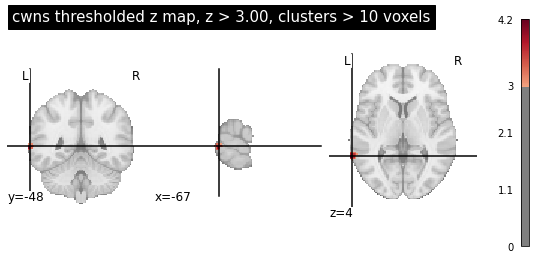

In [23]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    threshold=zthresh,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

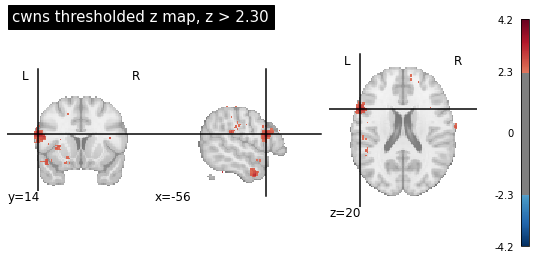

In [24]:
lower_thresh = 2.3
plotting.plot_stat_map(
    z_map, #cut_coords=[17,12,5], 
    threshold=lower_thresh,
    title=f'{group_label} thresholded z map, z > {lower_thresh:.02f}')


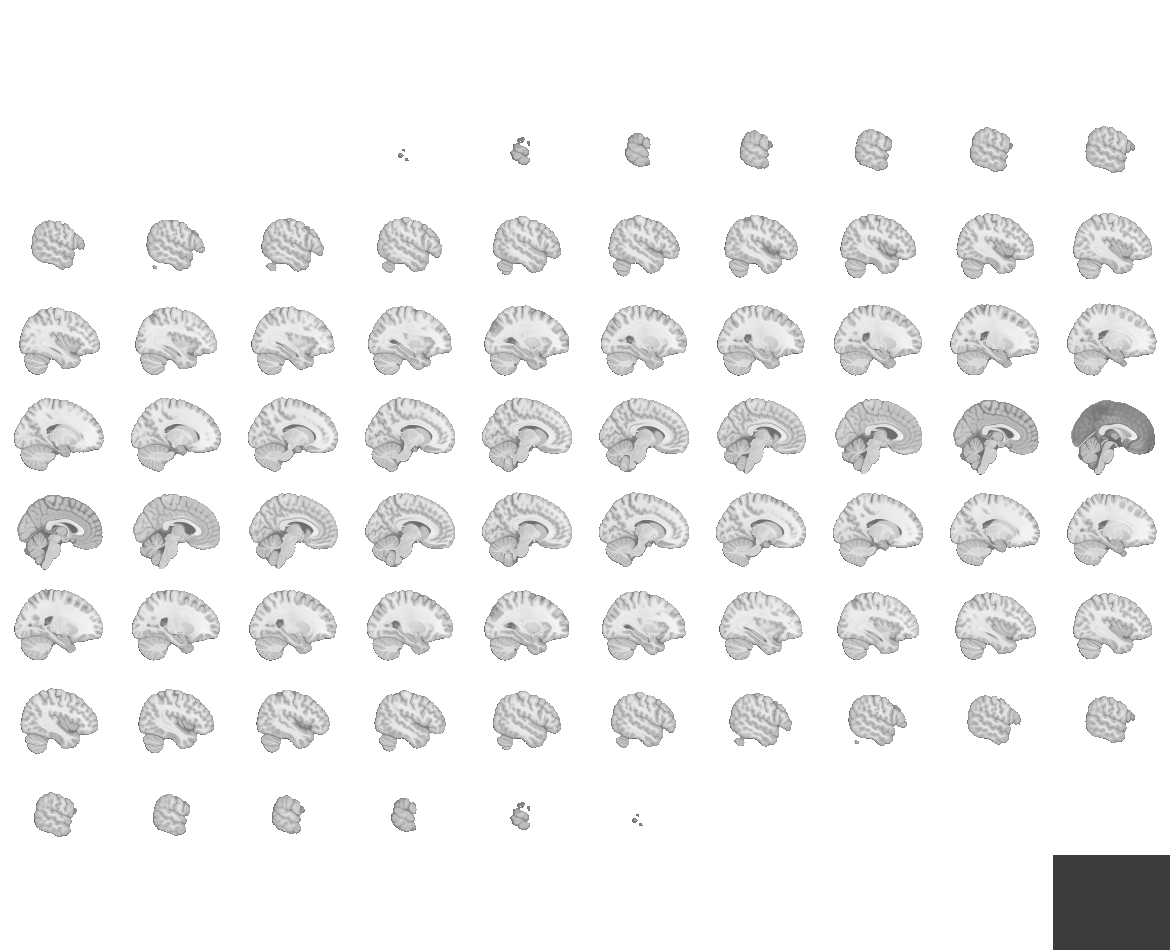
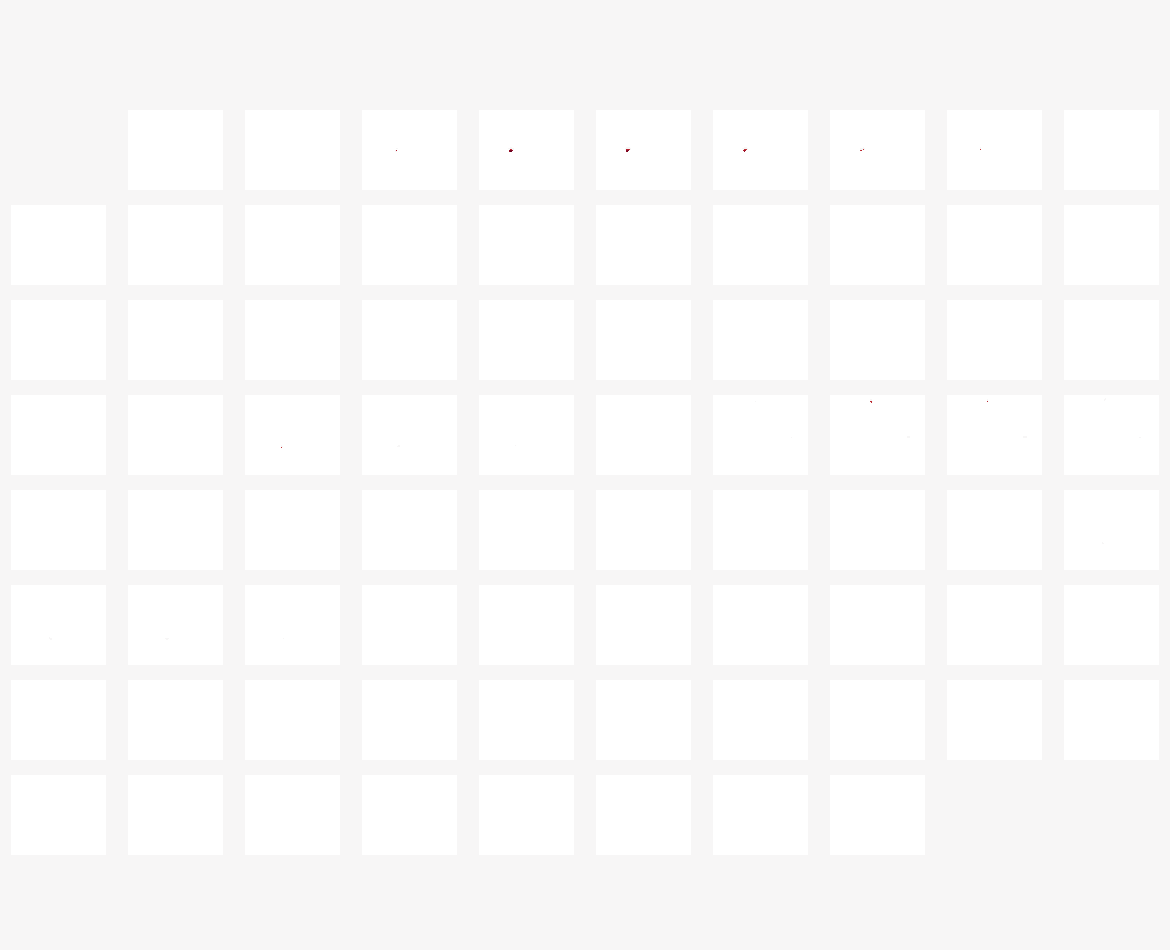

In [26]:
plotting.view_img(thresholded_map,
                  threshold=zthresh,
                  symmetric_cmap=True,
                  black_bg=False,
                  title=f'{group_label} {model_label} RSA')


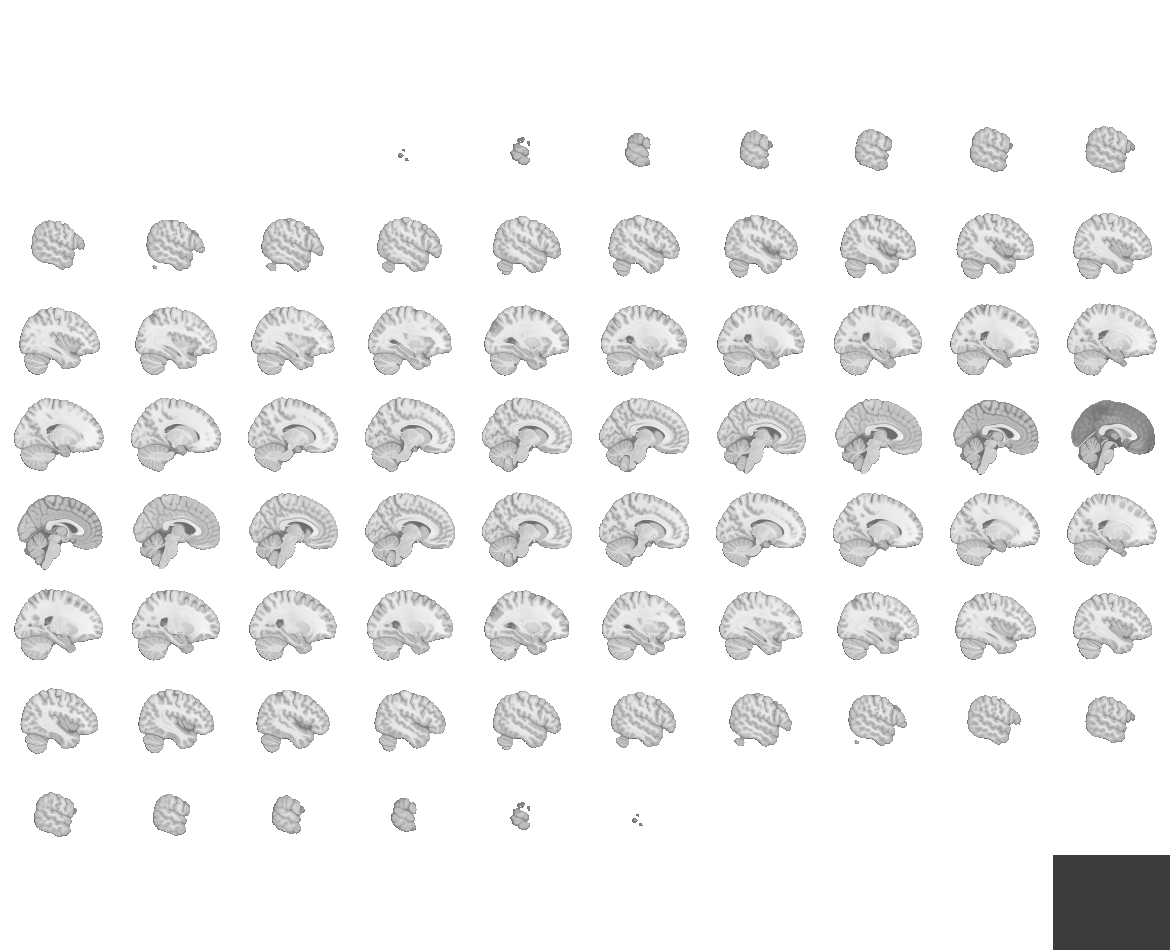
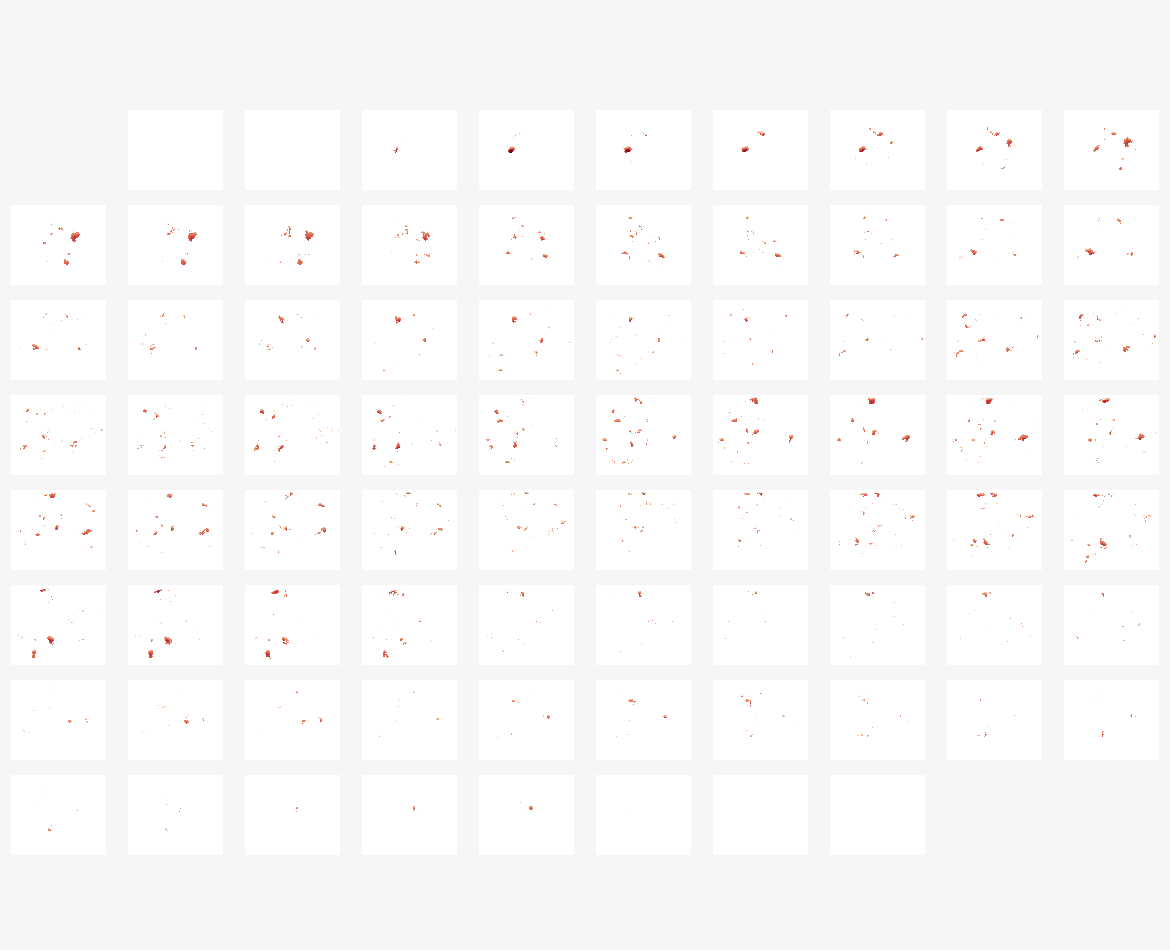

In [27]:
plotting.view_img(z_map, #thresholded_map,
                  threshold=lower_thresh,
                  symmetric_cmap=True,
                  black_bg=False,
                  title=f'{group_label} {model_label} RSA')

The None=0.05 threshold is 3


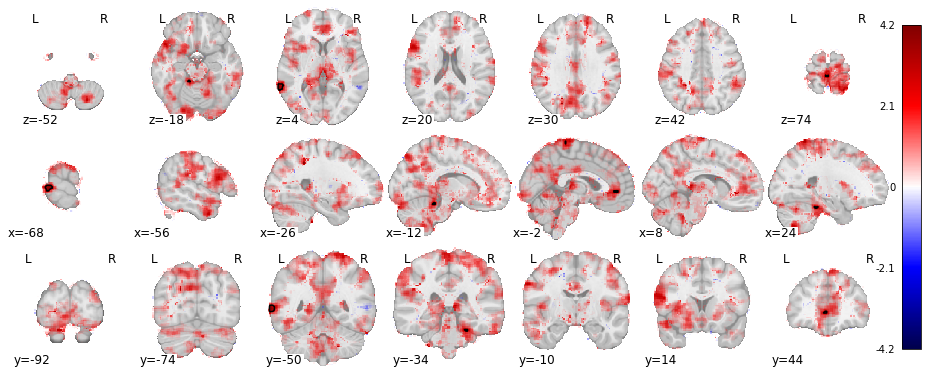

In [29]:
display = plotting.plot_stat_map(
    z_map, 
    bg_img=mni152_template,
    transparency=z_map, transparency_range=[1, zthresh],
    black_bg=False,
    display_mode='mosaic',
    cmap='seismic',
    )
display.add_contours(
    thresholded_map, filled=False, levels=[-zthresh, zthresh], colors=["k", "k"]
)

print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
display.savefig(#os.path.join(group_out_dir,
            f'group-{group_label}_rsa_contrast-{model_label}_view-mosaic.png',
            dpi=1000)#)

The None=0.05 threshold is 3


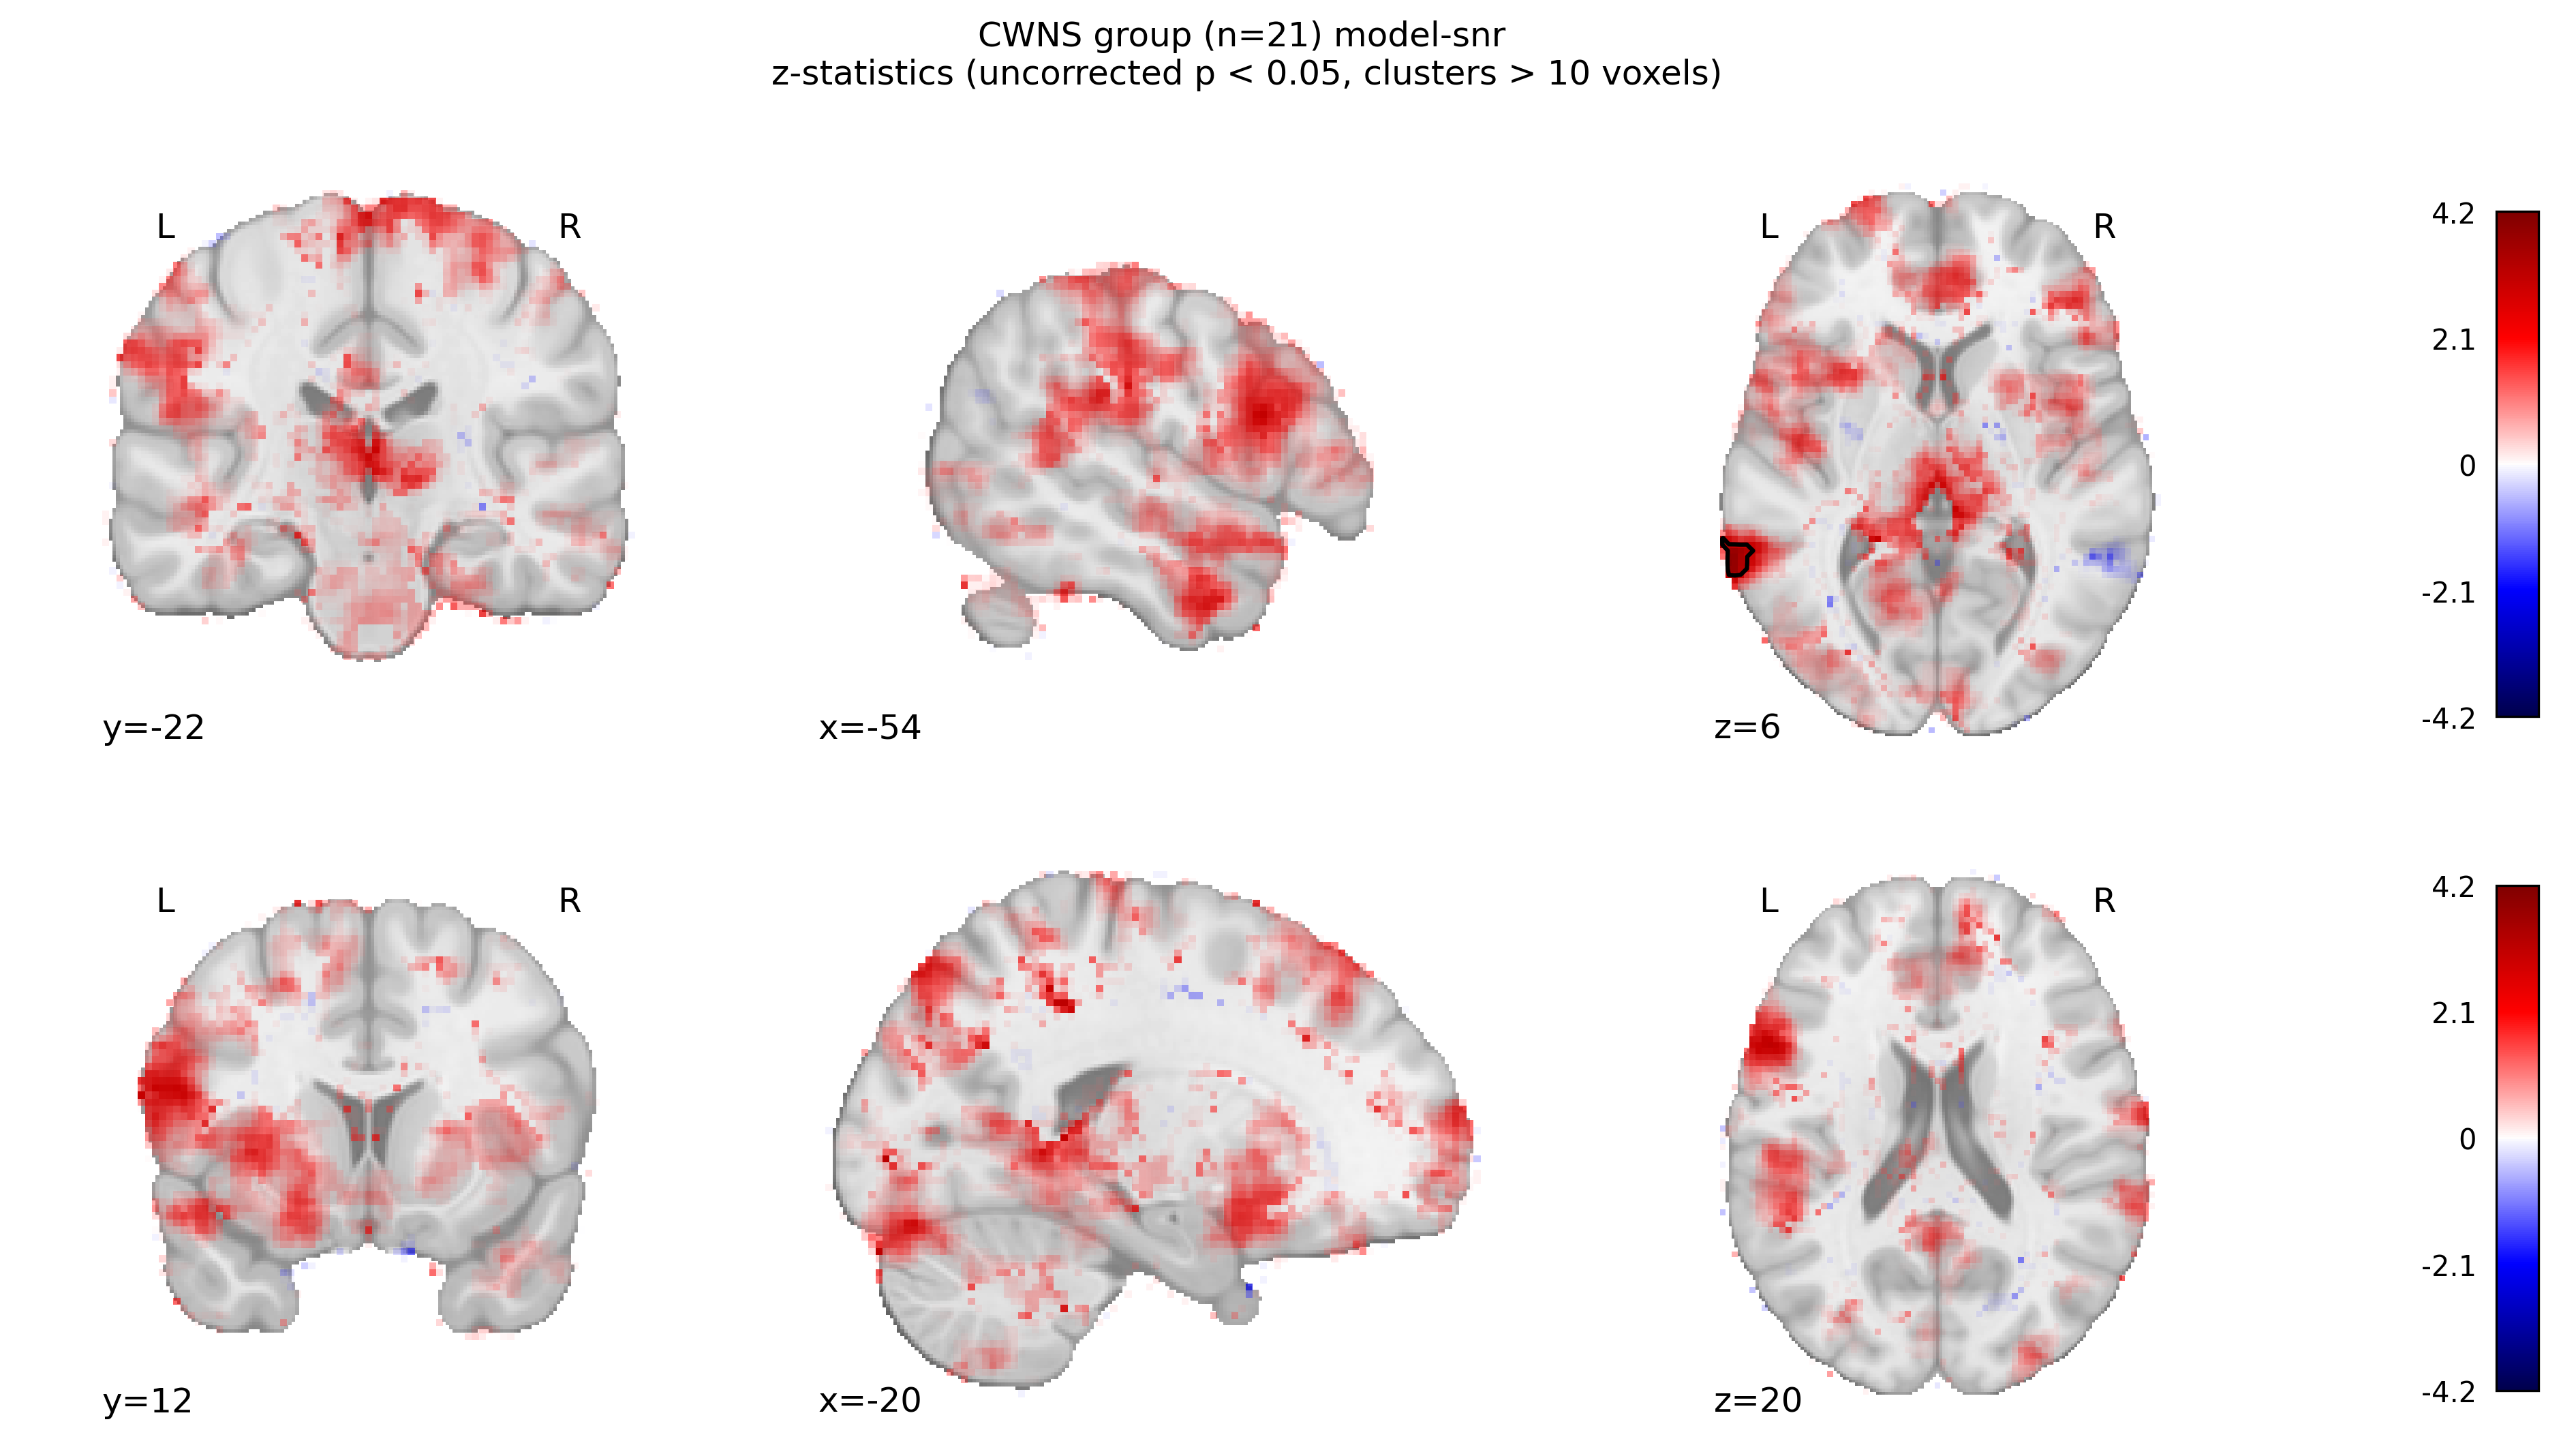

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8), dpi=300)

display = plotting.plot_stat_map(
    z_map, 
    #threshold=zthresh,
    bg_img=mni152_template,
    transparency=z_map, transparency_range=[1, zthresh],
    black_bg=False, annotate=True, draw_cross=False,
    cut_coords=[-54, -22, 6],
    cmap='seismic',
    #display_mode='mosaic',
    #title=plot_title,
    axes=ax[0])
display.add_contours(
    thresholded_map, filled=False, levels=[-zthresh, zthresh], colors=["k", "k"]
)

display = plotting.plot_stat_map(
    z_map, 
    #threshold=zthresh,
    bg_img=mni152_template,
    transparency=z_map, transparency_range=[1, zthresh],
    black_bg=False, annotate=True, draw_cross=False,
    cut_coords=[-20, 12, 20],
    cmap='seismic',
    #display_mode='mosaic',
    #title=plot_title,
    axes=ax[1])
display.add_contours(
    thresholded_map, filled=False, levels=[-zthresh, zthresh], colors=["k", "k"]
)

fig.suptitle(plot_title, fontsize=12);
print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
#fig.savefig(os.path.join(group_out_dir,
#                     f'group-{group_label}_space-{space_label}_contrast-{contrast_label}_view-ortho.png'))

In [ ]:
title = (f'group-{group_label} (n={len(sub_list_cwns)}) RSA-{model_label} \n'
              f'p < {alpha:.02f}, clusters > {cthresh} voxels')

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)

## Syllable model

In [98]:
model_label = model_list[1]

In [99]:
run_num = 1

l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/run-{run_num}/' +
                                   f'{sub_id}_{run_num}_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [100]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP008/run-1/sub-SSP008_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP009/run-1/sub-SSP009_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP011/run-1/sub-SSP011_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP015/run-1/sub-SSP015_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP017/run-1/sub-SSP017_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-

### loop through images and transform fisher's r-to-z

In [101]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [102]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [103]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [104]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific/group-cwns_model-syllable_map-zstat.nii.gz


In [105]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=False,
                        )

/scratch/slurm-6177251/ipykernel_2507282/2204551793.py:7: UserWarning: The given float value must not exceed 2.4689503567931474. But, you have given threshold=3.0.
  thresholded_map, zthresh = threshold_stats_img(


/scratch/slurm-6177251/ipykernel_2507282/897901959.py:1: UserWarning: empty mask
  plotting.plot_stat_map(


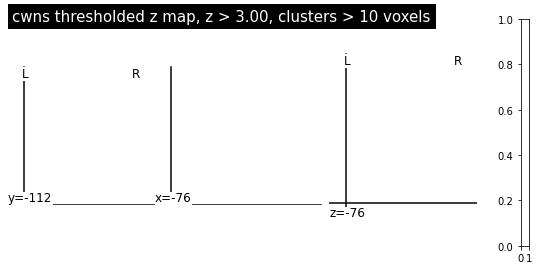

In [37]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    #threshold=threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

/scratch/slurm-6177251/ipykernel_2507282/1017615105.py:1: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(z_map, # thresholded_map, # z_map,



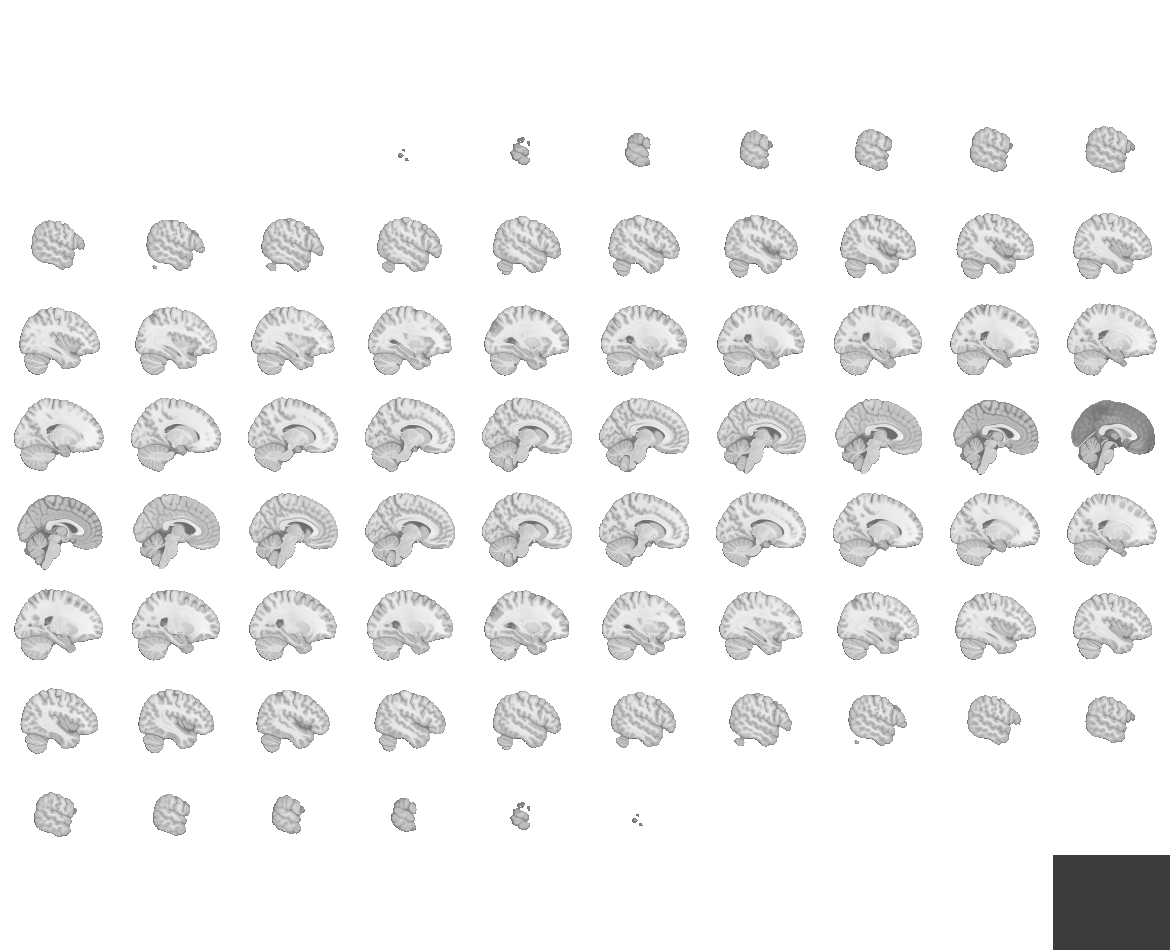
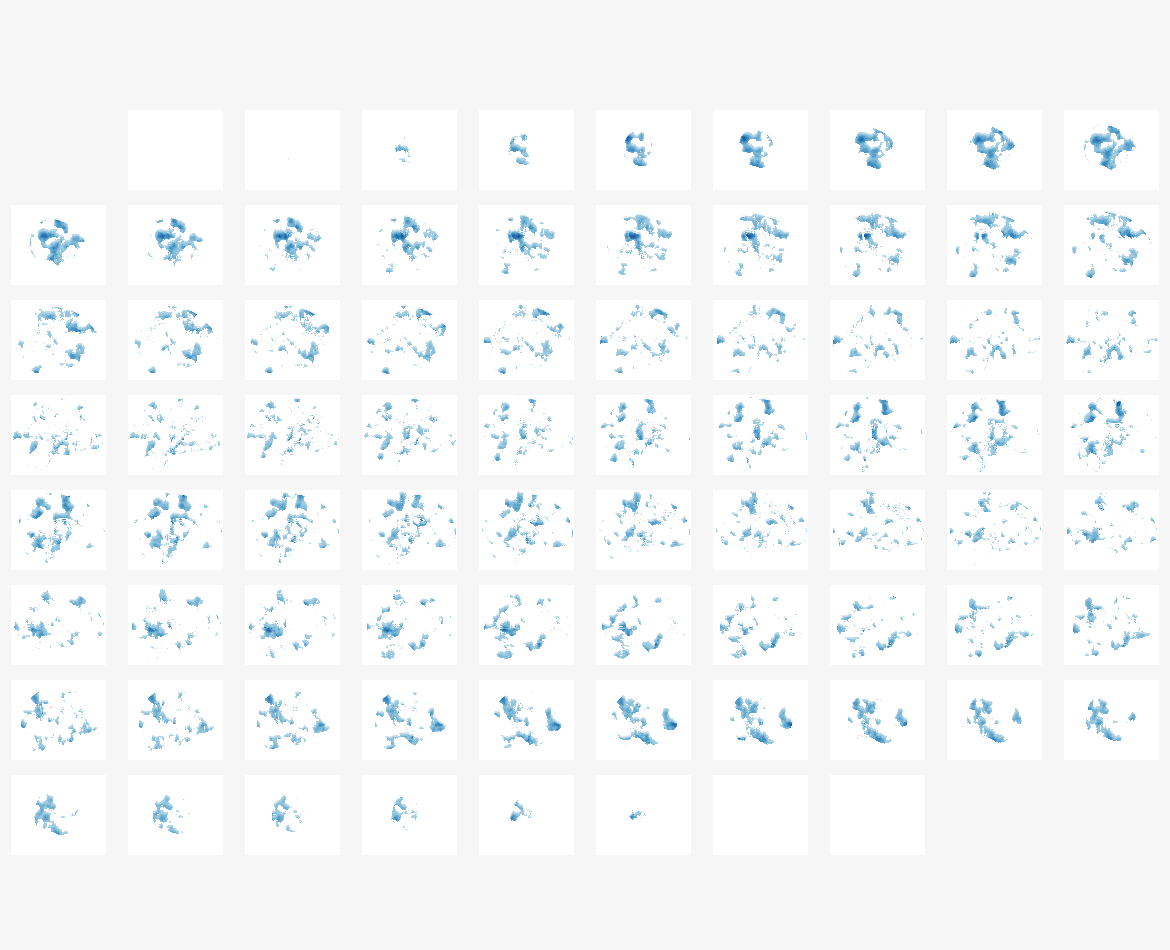

In [108]:
plotting.view_img(z_map, # thresholded_map, z_map,
                  threshold=1.7, #threshold
                  symmetric_cmap=True,
                  black_bg=False,
                  title=f'{group_label} {model_label} RSA')

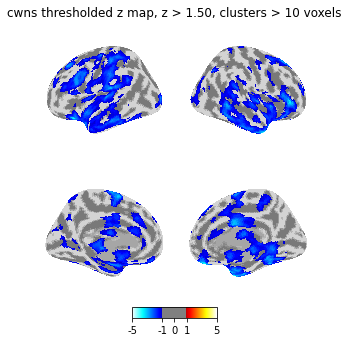

In [67]:
threshold = 1.5
plotting.plot_img_on_surf(z_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

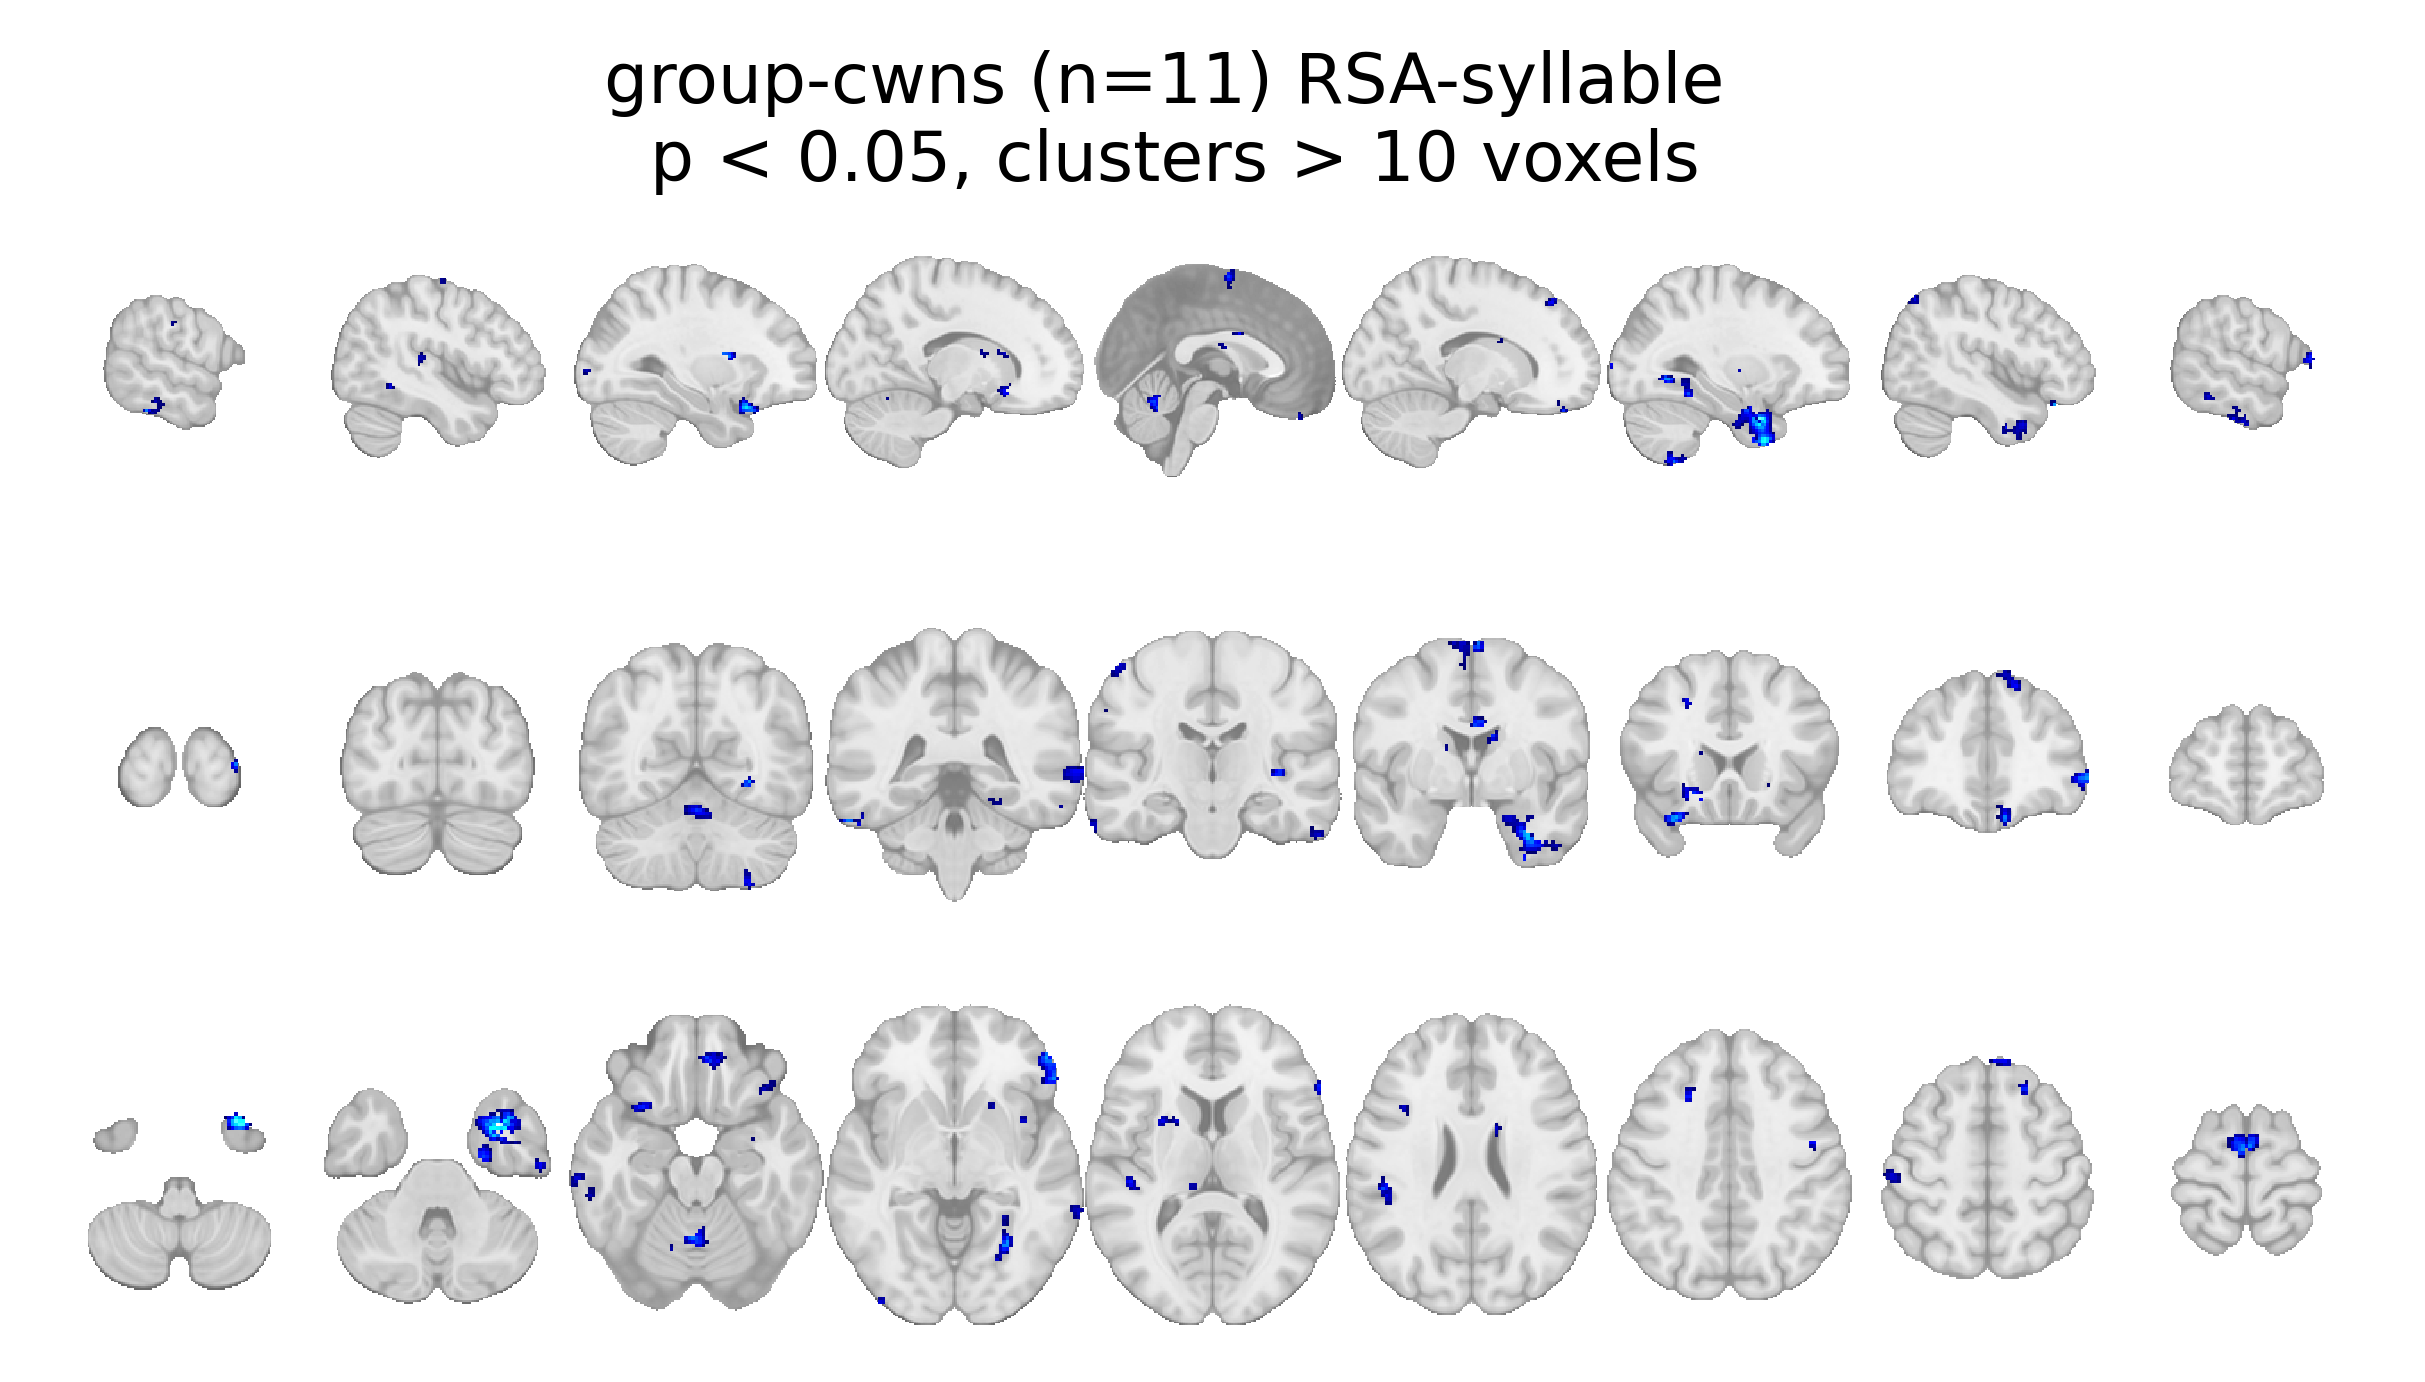

In [68]:
title = (f'group-{group_label} (n=%d) RSA-%s \n'
              'p < %.02f, clusters > %d voxels'%(len(sub_list_cwns), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)

In [ ]:
for group_label in ['Mand', 'NMan', 'diff-Mand-gt-NMan']: #
    for model_label in model_list:
        img_fname = 'group-{}_rsa-searchlight_model-{}_map-zstat.nii.gz'.format(group_label, model_label)
        img_fpath = os.path.join(l2_dir, img_fname)

        fig_fpath = os.path.join('level-2_out', 
                                 'group-{}_rsa-searchlight_model-{}_map-zstat.png'.format(group_label, 
                                                                                          model_label))
        title='group-%s model-%s\nz > %.02f – clusters > %d voxels'%(group_label, model_label, threshold, cthresh)
        threshold = 2.58
        cthresh = 10
        thresholded_map = threshold_img(
                                        img_fpath,
                                        threshold=threshold,
                                        cluster_threshold=cthresh,
                                        two_sided=True,
                                    )
        #fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5,4), dpi=500)
        fig, ax = plotting.plot_img_on_surf(thresholded_map,
                                  surf_mesh='fsaverage',
                                  views=['lateral', 'medial'],
                                  hemispheres=['left', 'right'],
                                  inflate=True,
                                  threshold=threshold,
                                  colorbar=True,
                                  title=title,
                                  #kwargs={'figure':fig, 'axes':ax}
                                 )
        fig.savefig(fig_fpath)
        print('file saved to ', fig_fpath)

In [ ]:
threshold = 2.58
cthresh = 10
    
for group_label in ['Mand', 'NMan', 'diff-Mand-gt-NMan']: # 'Mand', 'NMan', 'diff-Mand-gt-NMan'
    for model_label in model_list:
        title='group-%s model-%s \n z > %.02f – clusters > %d voxels'%(group_label, model_label, threshold, cthresh)
        
        #fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
        #subfigs = fig.subfigures(nrows=3, ncols=1)
        fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
        fig.suptitle(title)
        
        img_fname = 'group-{}_rsa-searchlight_model-{}_map-zstat.nii.gz'.format(group_label, model_label)
        img_fpath = os.path.join(l2_dir, img_fname)

        fig_fpath = os.path.join('level-2_out', 
                                 'group-{}_rsa-searchlight_model-{}_map-zstat_slice.png'.format(group_label, 
                                                                                          model_label))
        thresholded_map = threshold_img(
                                        img_fpath,
                                        threshold=threshold,
                                        cluster_threshold=cthresh,
                                        two_sided=True,
                                    )

        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='x',
                               cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               figure=fig, 
                               axes=axes[0])
        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='y',
                               cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               figure=fig, 
                               axes=axes[1])
        plotting.plot_stat_map(thresholded_map, 
                               bg_img=mni152_template, 
                               black_bg=False,
                               display_mode='z',
                               cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                               colorbar=False,
                               annotate=False,
                               #title=title,
                               #figure=fig, 
                               axes=axes[2])
        
        fig.savefig(fig_fpath)
        print('file saved to ', fig_fpath)

# Per run

### Get files

In [48]:
fwhm = 0.00
searchrad = 5
model_label = 'run-specific' # 'run-all'
space_label = 'MNI152NLin2009cAsym'
l1_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'rsa-searchlight_run-specific')
l2_dir = os.path.join(bidsroot, 'derivatives', 
                      'nilearn', f'group_rsa-searchlight_run-specific')
os.makedirs(l2_dir, exist_ok=True)

In [49]:
l2_dir

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific'

In [50]:
model_list = ['snr', 'syllable']

## SNR model

In [51]:
model_label = model_list[0]

In [76]:
run_num = 1

l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/run-{run_num}/' +
                                   f'{sub_id}_{run_num}_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [77]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP008/run-1/sub-SSP008_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP009/run-1/sub-SSP009_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP011/run-1/sub-SSP011_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP015/run-1/sub-SSP015_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP017/run-1/sub-SSP017_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-snr.nii.

### loop through images and transform fisher's r-to-z

In [78]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [79]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [80]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [81]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific/group-cwns_model-snr_map-zstat.nii.gz


In [92]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 5
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=False,
                        )

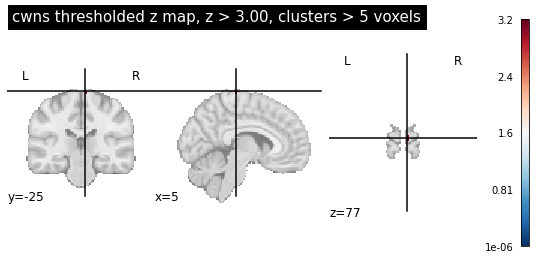

In [93]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    #threshold=threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

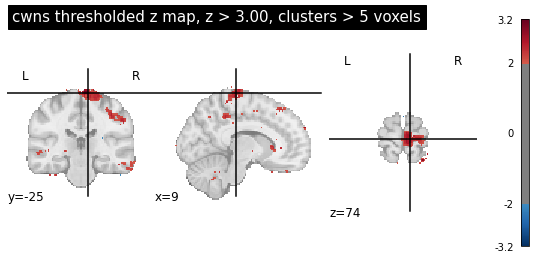

In [94]:
plotting.plot_stat_map(
    z_map, #cut_coords=[17,12,5], 
    threshold=2,#threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

/scratch/slurm-6177251/ipykernel_2507282/2303291041.py:1: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(z_map, #thresholded_map,



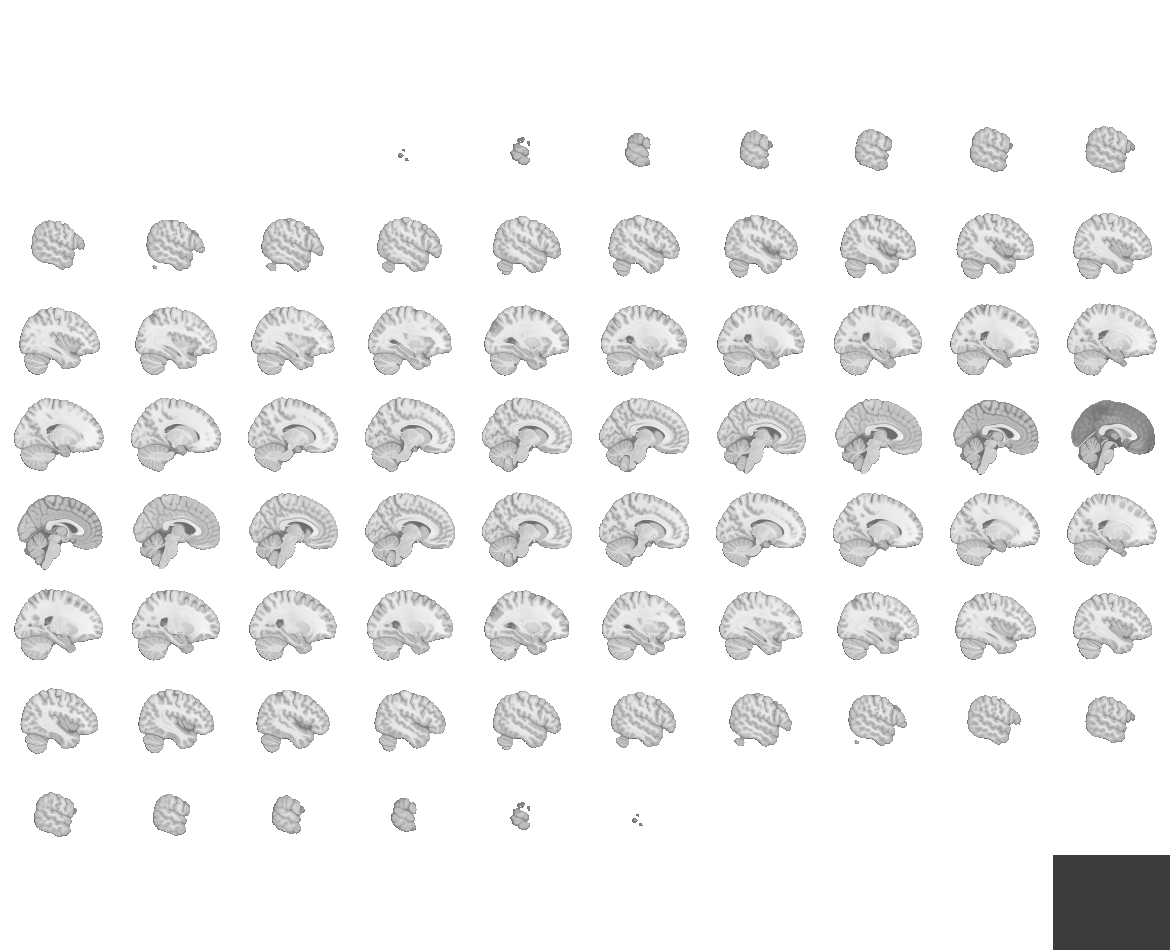
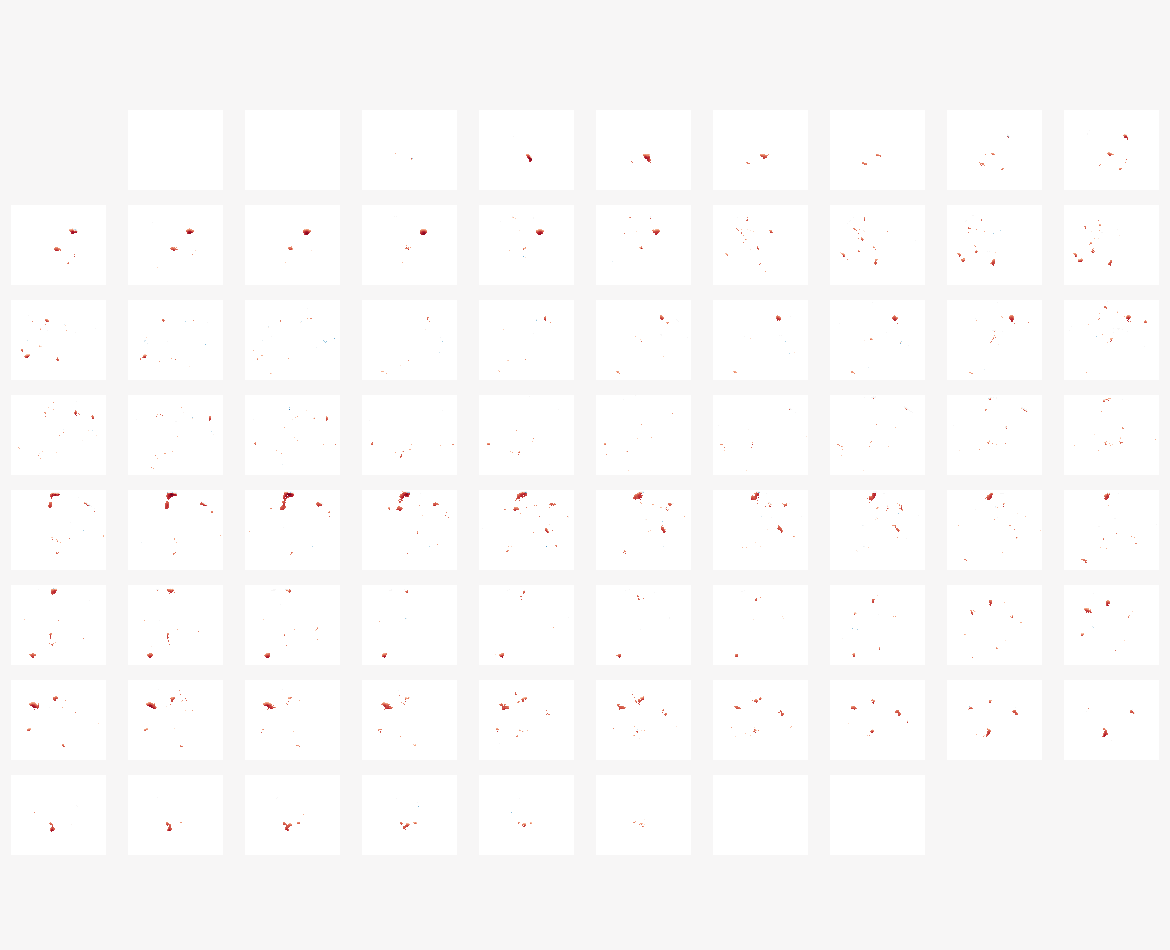

In [95]:
plotting.view_img(z_map, #thresholded_map,
                  threshold=2,
                  symmetric_cmap=True,
                  black_bg=False,
                  title=f'{group_label} {model_label} RSA')

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/plotting/surface/_backend.py:74: UserWarning: 'symmetric_cmap' is not implemented for the matplotlib engine.
Got 'symmetric_cmap = True'.
Use 'symmetric_cmap = None' to silence this warning.
  warn(
/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/plotting/surface/_backend.py:74: UserWarning: 'title_font_size' is not implemented for the matplotlib engine.
Got 'title_font_size = 18'.
Use 'title_font_size = None' to silence this warning.
  warn(


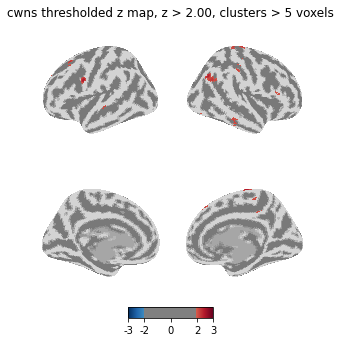

In [96]:
threshold = 2.
plotting.plot_img_on_surf(z_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

In [ ]:
title = (f'group-{group_label} (n={len(sub_list_cwns)}) RSA-{model_label} \n'
              f'p < {alpha:.02f}, clusters > {cthresh} voxels')

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)

## Syllable model

In [98]:
model_label = model_list[1]

In [99]:
run_num = 1

l1_fnames_groupdiff = [sorted(glob(l1_dir+f'/{sub_id}/run-{run_num}/' +
                                   f'{sub_id}_{run_num}_fwhm-{fwhm:.02f}_searchvox-{searchrad}_rsa-searchlight_contrast-sound_model-{model_label}.nii.gz'))[0] for sub_id in subjects_label]

In [100]:
l1_fnames_groupdiff

['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP008/run-1/sub-SSP008_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP009/run-1/sub-SSP009_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP011/run-1/sub-SSP011_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP015/run-1/sub-SSP015_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-sound_model-syllable.nii.gz',
 '/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/rsa-searchlight_run-specific/sub-SSP017/run-1/sub-SSP017_1_fwhm-0.00_searchvox-5_rsa-searchlight_contrast-

### loop through images and transform fisher's r-to-z

In [101]:
diff_img_list = []

for sx, sub_sl_fpath in enumerate(l1_fnames_groupdiff):
    
    sub_sl_img = nib.load(sub_sl_fpath)
    sub_sl_data = sub_sl_img.get_fdata()

    # fisher transform r-to-z
    diff_data = np.arctanh(sub_sl_data)

    diff_img = new_img_like(sub_sl_img, diff_data)

    diff_img_list.append(diff_img)

### CWNS group RSA

In [102]:
#second_level_model = SecondLevelModel().fit(smoothed_l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)
second_level_model = SecondLevelModel().fit(diff_img_list, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[0, 1,], output_type='z_score')

In [103]:
group_label = 'cwns'
out_fname = f'group-{group_label}_model-{model_label}_map-zstat.nii.gz'
out_fpath = os.path.join(l2_dir, out_fname)
nib.save(z_map, out_fpath)

In [104]:
print(out_fpath)

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/group_rsa-searchlight_run-specific/group-cwns_model-syllable_map-zstat.nii.gz


In [105]:
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=False,
                        )

/scratch/slurm-6177251/ipykernel_2507282/2204551793.py:7: UserWarning: The given float value must not exceed 2.4689503567931474. But, you have given threshold=3.0.
  thresholded_map, zthresh = threshold_stats_img(


/scratch/slurm-6177251/ipykernel_2507282/897901959.py:1: UserWarning: empty mask
  plotting.plot_stat_map(


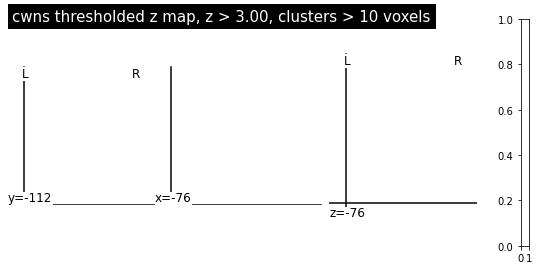

In [37]:
plotting.plot_stat_map(
    thresholded_map, #cut_coords=[17,12,5], 
    #threshold=threshold,
    title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, zthresh, cthresh))

/scratch/slurm-6177251/ipykernel_2507282/1017615105.py:1: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(z_map, # thresholded_map, # z_map,



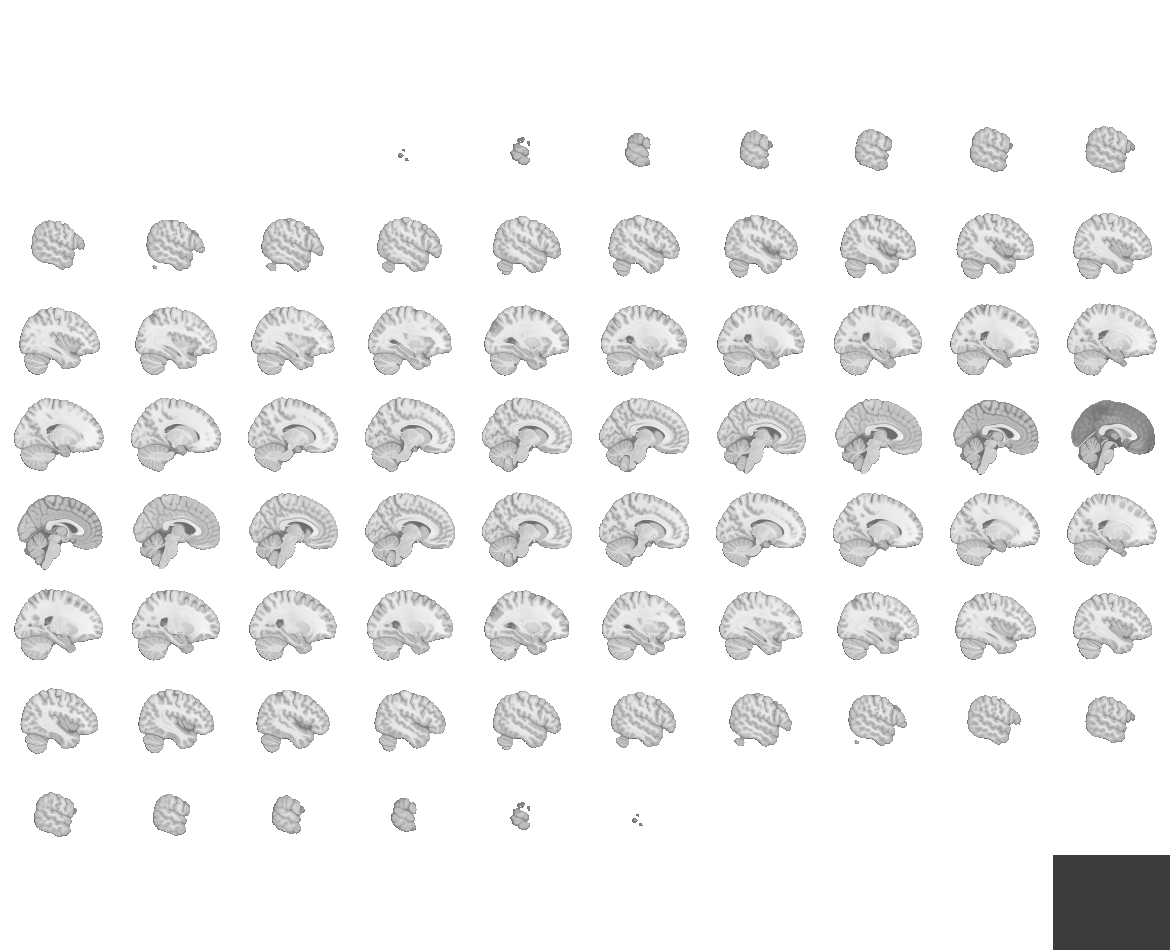
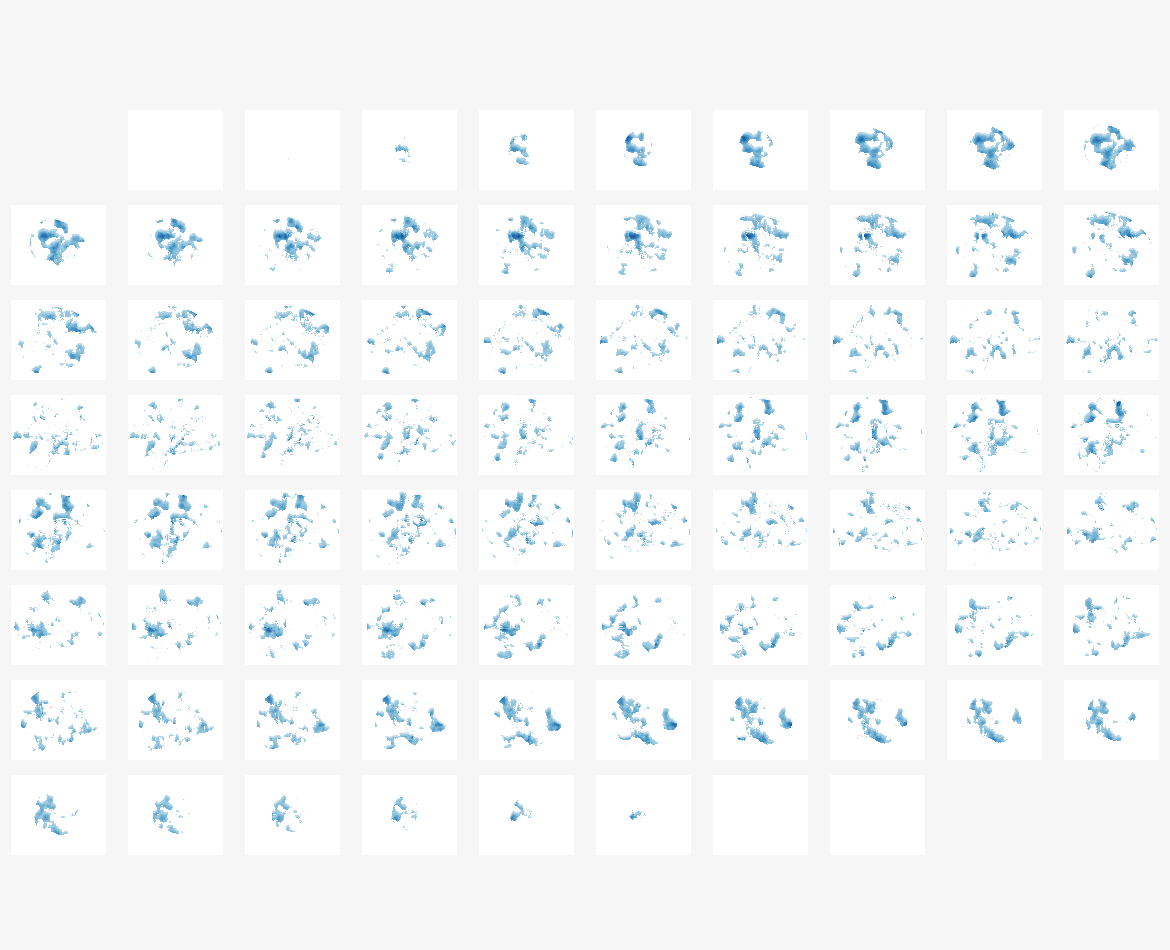

In [108]:
plotting.view_img(z_map, # thresholded_map, z_map,
                  threshold=1.7, #threshold
                  symmetric_cmap=True,
                  black_bg=False,
                  title=f'{group_label} {model_label} RSA')

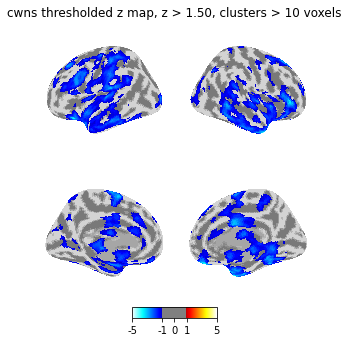

In [67]:
threshold = 1.5
plotting.plot_img_on_surf(z_map,
                          #surf_mesh='fsaverage', # comment out for faster default (fsaverage5)
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=threshold,
                          #cmap='Reds',
                          colorbar=True,
                          title='%s thresholded z map, z > %.02f, clusters > %d voxels'%(group_label, threshold, cthresh))
plotting.show()

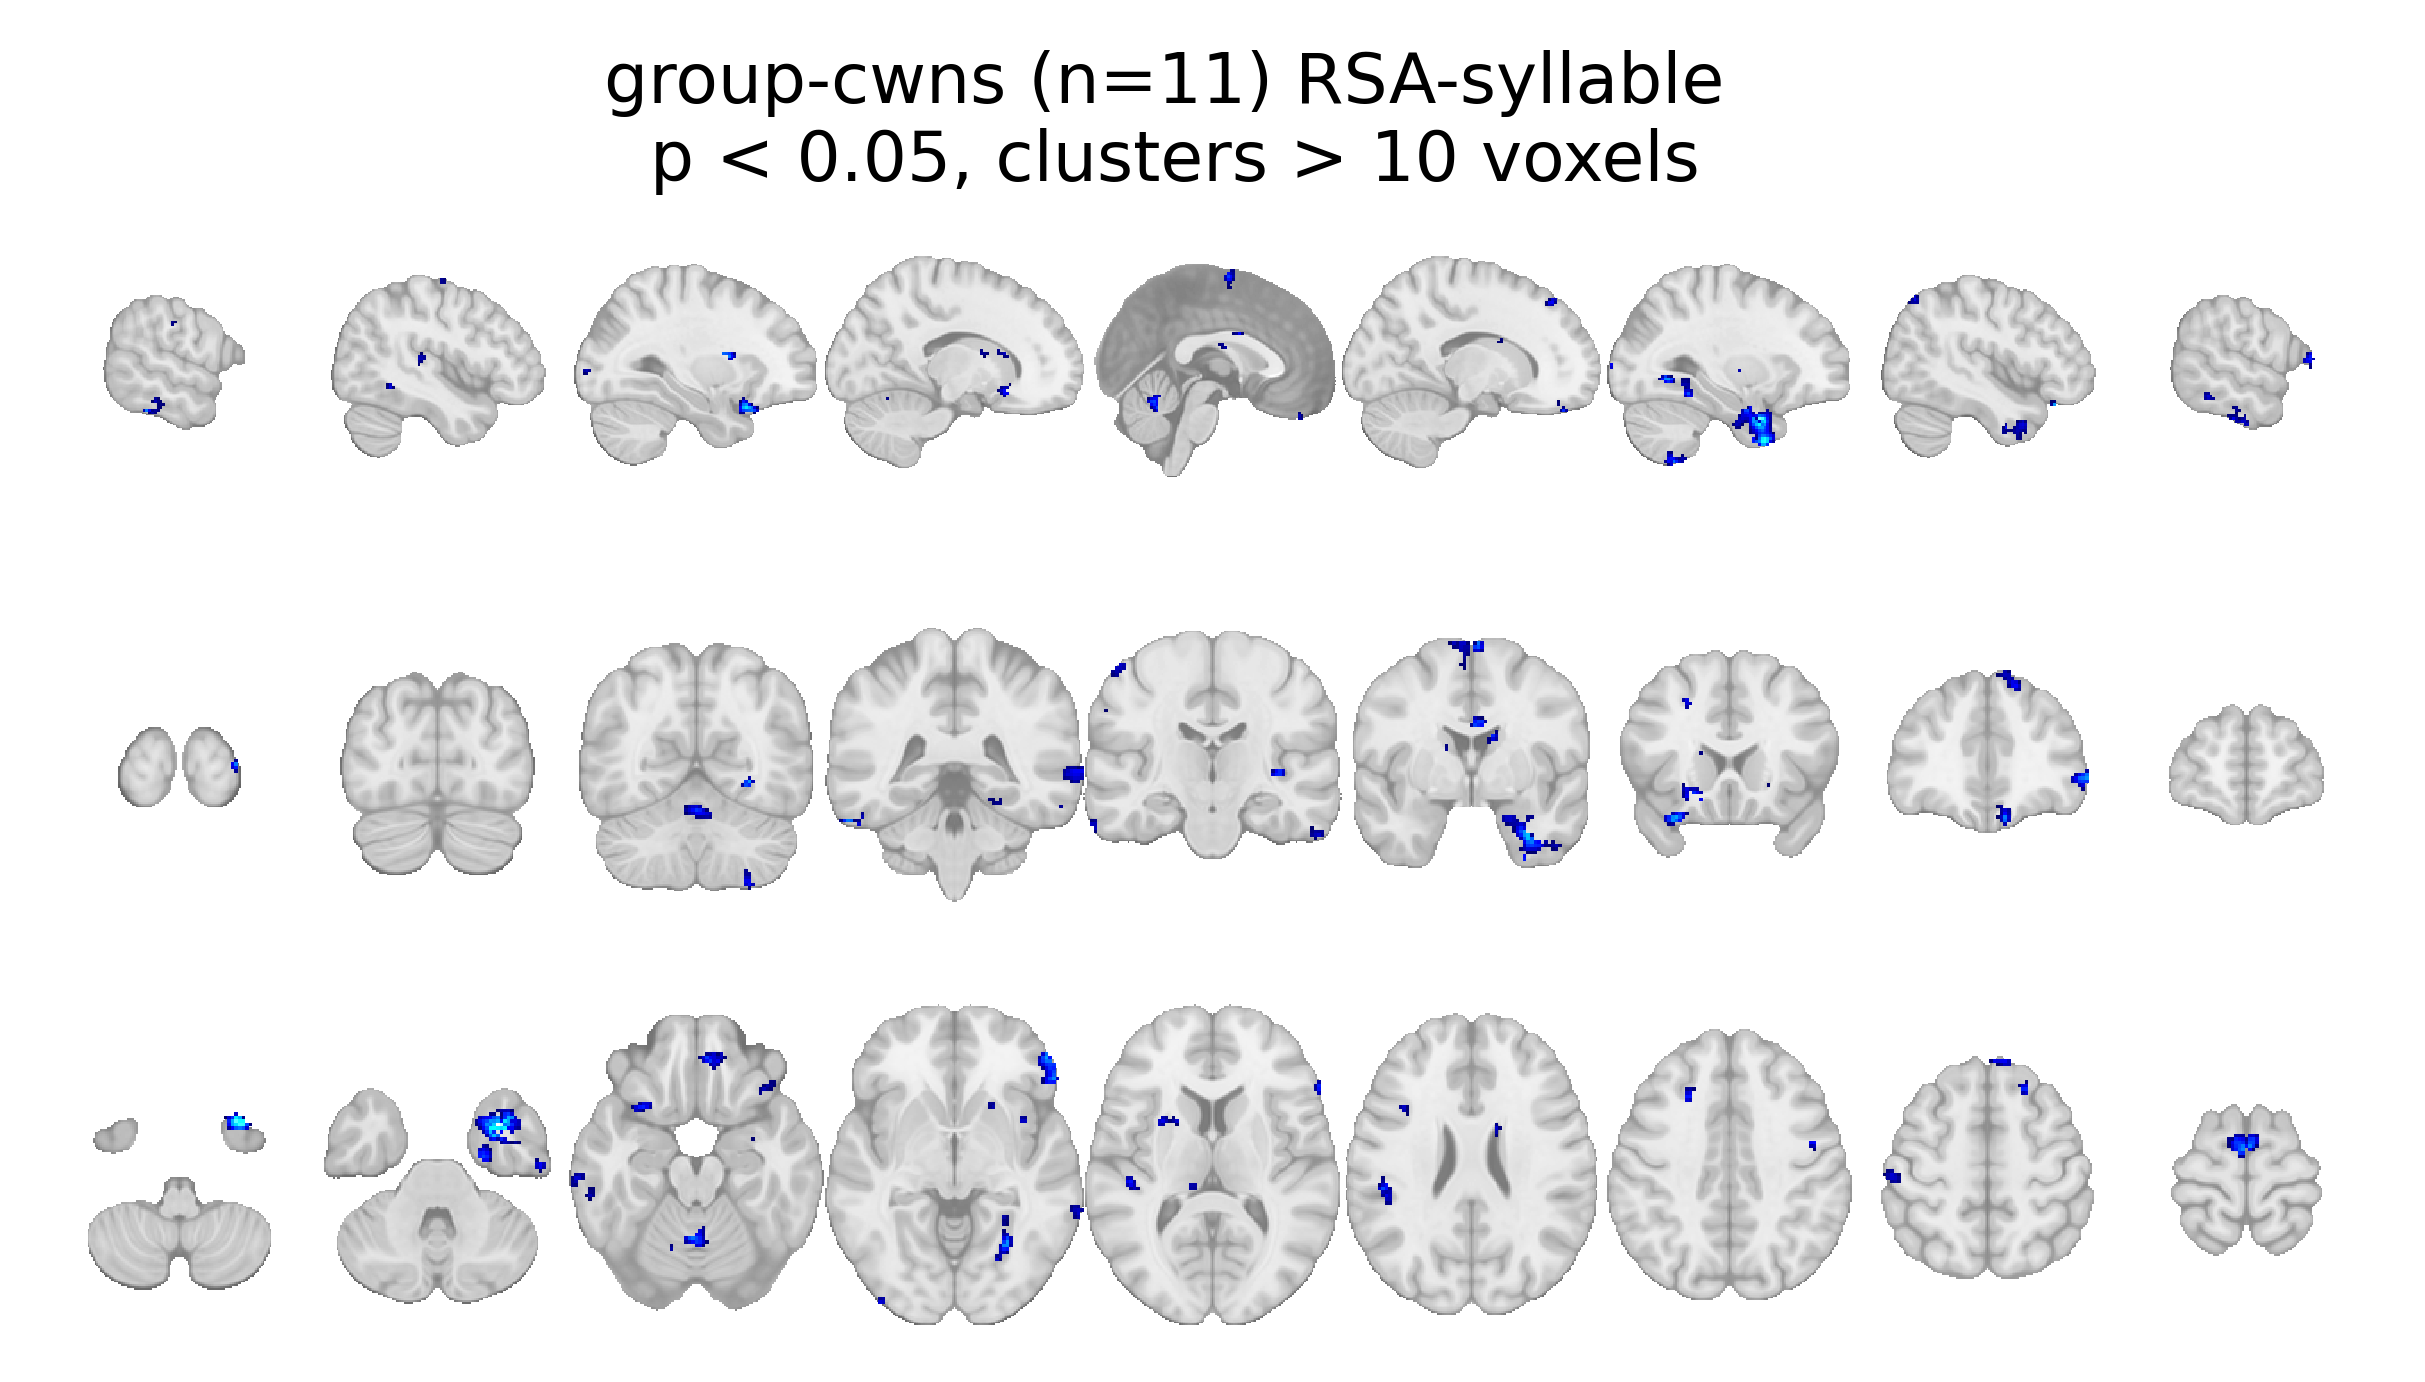

In [68]:
title = (f'group-{group_label} (n=%d) RSA-%s \n'
              'p < %.02f, clusters > %d voxels'%(len(sub_list_cwns), model_label, alpha, cthresh))

#fig = plt.figure(constrained_layout=True, figsize=(8,4), dpi=500)
#subfigs = fig.subfigures(nrows=3, ncols=1)
fig, axes = plt.subplots(3, 1, figsize=(6,3), dpi=500)
fig.suptitle(title, fontsize='medium')

fig_fpath = os.path.join(l2_dir, 
                         f'group-{group_label}_rsa-searchlight_model-{model_label}_searchrad-{searchrad}_fwhm-{fwhm}_map-zstat_slice.png')

plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='x',
                       cut_coords=[-60, -45, -30, -15, 0, 15, 30, 45, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[0])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='y',
                       cut_coords=[-100, -80, -60, -40, -20, 0, 20, 40, 60],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       figure=fig, 
                       axes=axes[1])
plotting.plot_stat_map(thresholded_map, 
                       bg_img=mni152_template, 
                       black_bg=False,
                       display_mode='z',
                       cut_coords=[-50, -35, -20, -5, 10, 25, 40, 55, 70],
                       colorbar=False,
                       annotate=False,
                       #title=title,
                       #figure=fig, 
                       axes=axes[2])

#fig.savefig(fig_fpath)
#print('file saved to ', fig_fpath)

# RSA – categorical models

In [110]:

# Based on the rsatoolbox tutorial: https://rsatoolbox.readthedocs.io/en/stable/demo_searchlight.html
import os
import argparse
import sys
import itertools

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import seaborn as sns

from rsatoolbox.model import ModelFixed, Model
from rsatoolbox.rdm import RDMs

from glob import glob

In [111]:
# Define categorical variables
snrs = ["Q", "8", "0", "N2", "N6"]  # 5 SNRs
syllables = ["ba", "da", "ga", "ma"]  # 4 Syllables
talkers = ["F1", "F2", "M1", "M2"]  # 4 Talkers

cat_label_list = ['snr', 'syllable', 'talker']

# Generate all possible stimuli (5 SNRs × 4 Syllables × 4 Talkers = 80 stimuli)
stimuli = list(itertools.product(snrs, syllables, talkers))  # 80 stimuli

# Create the pattern_descriptors dictionary
pattern_descriptors = {
    idx: {"SNR": stim[0], "Syllable": stim[1], "Talker": stim[2]} 
    for idx, stim in enumerate(stimuli)
}

# Initialize RDMs (80x80 matrices)
rdm_snr = np.zeros((80, 80), dtype=int)
rdm_syllable = np.zeros((80, 80), dtype=int)
rdm_talker = np.zeros((80, 80), dtype=int)

# Fill RDMs
for i in range(80):
    for j in range(80):
        # SNR RDM: 1 if different SNRs, 0 if same
        rdm_snr[i, j] = 1 if stimuli[i][0] != stimuli[j][0] else 0

        # Syllable RDM: 1 if different syllables, 0 if same
        rdm_syllable[i, j] = 1 if stimuli[i][1] != stimuli[j][1] else 0

        # Talker RDM: 1 if different talkers, 0 if same
        rdm_talker[i, j] = 1 if stimuli[i][2] != stimuli[j][2] else 0

# Print matrix dimensions to confirm correctness
print("Syllable RDM shape:", rdm_syllable.shape)
print("SNR RDM shape:", rdm_snr.shape)
print("Talker RDM shape:", rdm_talker.shape)

# convert to models
rdms_array = np.array([rdm_snr, rdm_syllable, rdm_talker])

model_rdms = RDMs(rdms_array,
                  rdm_descriptors={'categorical_model':cat_label_list,},
                  #pattern_descriptors=pattern_descriptors,
                  dissimilarity_measure='Euclidean'
                 )

snr_rdms = model_rdms.subset('categorical_model','snr')
syllable_rdms = model_rdms.subset('categorical_model','syllable')
syllable_rdms = model_rdms.subset('categorical_model','talker')


Syllable RDM shape: (80, 80)
SNR RDM shape: (80, 80)
Talker RDM shape: (80, 80)


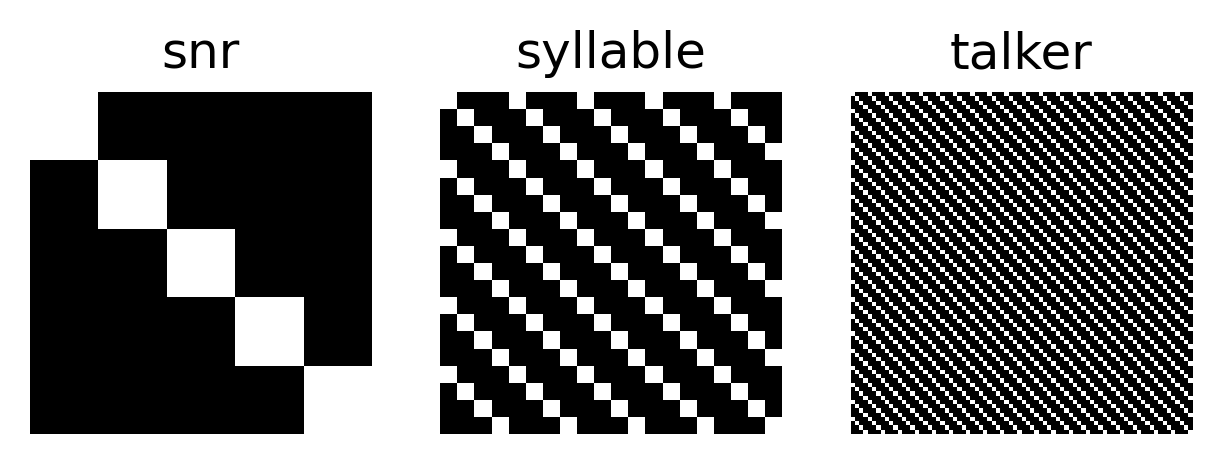

In [112]:
fig, ax = plt.subplots(1,3, figsize=(5,4), dpi=300)
for rx, rdm in enumerate(rdms_array):
    sns.heatmap(rdm, 
                cmap='Greys', square=True, cbar=False, 
                xticklabels=False, yticklabels=False,
                ax=ax[rx])
    ax[rx].set_title(cat_label_list[rx])